# 🔍 AI-Generated Image Detection
## Hybrid EfficientNetB2 + Vision Transformer (ViT) Model
**Binary Classification: Real (0) vs AI-Generated (1)**

## 📦 Section 1: Install Dependencies

In [1]:
# Run this ONCE to install required libraries
!pip install torch torchvision transformers scikit-learn seaborn matplotlib pillow

## 📚 Section 2: Imports

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader

from transformers import ViTModel
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# Check device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


## 🗂️ Section 3: Dataset Loading
**Set your folder paths below**

In [3]:
# ✅ SET YOUR PATHS HERE
real_path = r"C:\Users\visha\Desktop\dataset\real"
fake_path = r"C:\Users\visha\Desktop\dataset\fake"

image_paths = []
labels = []

# Supported image formats
valid_exts = ('.jpg', '.jpeg', '.png', '.bmp', '.webp')

# Real images → label 0
for img in os.listdir(real_path):
    if img.lower().endswith(valid_exts):
        image_paths.append(os.path.join(real_path, img))
        labels.append(0)

# Fake/AI images → label 1
for img in os.listdir(fake_path):
    if img.lower().endswith(valid_exts):
        image_paths.append(os.path.join(fake_path, img))
        labels.append(1)

print(f"Total images loaded : {len(image_paths)}")
print(f"Real images         : {labels.count(0)}")
print(f"AI-Generated images : {labels.count(1)}")

Total images loaded : 973
Real images         : 434
AI-Generated images : 539


## ✂️ Section 4: Train / Test Split (80-20 Stratified)

In [4]:
train_paths, test_paths, train_labels, test_labels = train_test_split(
    image_paths,
    labels,
    test_size=0.2,
    stratify=labels,   # Keeps class balance
    random_state=42
)

print(f"Training samples : {len(train_paths)}")
print(f"Testing  samples : {len(test_paths)}")
print(f"Train class dist : Real={train_labels.count(0)}, Fake={train_labels.count(1)}")
print(f"Test  class dist : Real={test_labels.count(0)}, Fake={test_labels.count(1)}")

Training samples : 778
Testing  samples : 195
Train class dist : Real=347, Fake=431
Test  class dist : Real=87, Fake=108


## 🔄 Section 5: Preprocessing & Augmentation

In [5]:
# Training transforms (with augmentation)
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std=[0.5, 0.5, 0.5])   # Required for ViT
])

# Test transforms (NO augmentation — evaluate on clean data)
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std=[0.5, 0.5, 0.5])
])

print("Transforms ready ✅")

Transforms ready ✅


## 📁 Section 6: Custom Dataset Class

In [6]:
class ImageDataset(Dataset):
    def __init__(self, paths, labels, transform=None):
        self.paths = paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        try:
            img = Image.open(self.paths[idx]).convert("RGB")
        except Exception:
            # If image is corrupt, return a blank image
            img = Image.new("RGB", (224, 224))

        label = self.labels[idx]

        if self.transform:
            img = self.transform(img)

        return img, label


# Build datasets
train_dataset = ImageDataset(train_paths, train_labels, train_transform)
test_dataset  = ImageDataset(test_paths,  test_labels,  test_transform)

# Build data loaders
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True,  num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=16, shuffle=False, num_workers=0)

# Sanity check
images, lbls = next(iter(train_loader))
print(f"Batch shape : {images.shape}")
print(f"Labels      : {lbls[:8].tolist()}")

Batch shape : torch.Size([16, 3, 224, 224])
Labels      : [0, 1, 0, 1, 0, 0, 1, 1]


## 🧠 Section 7: Hybrid CNN + ViT Model Architecture

In [7]:
class HybridModel(nn.Module):
    """
    Hybrid Architecture:
        Image
          |
    ------+------
    |           |
  CNN         ViT
(EfficientB2) (ViT-Base)
    |           |
    +---Concat--+
          |
       Dense(1)
          |
       Sigmoid
          |
    0=Real  1=Fake
    """

    def __init__(self):
        super(HybridModel, self).__init__()

        # ── CNN Branch: EfficientNetB2 ──
        self.cnn = models.efficientnet_b2(weights=models.EfficientNet_B2_Weights.DEFAULT)
        cnn_out_features = self.cnn.classifier[1].in_features  # 1408
        self.cnn.classifier = nn.Identity()  # Remove original head

        # ── ViT Branch ──
        self.vit = ViTModel.from_pretrained('google/vit-base-patch16-224')
        vit_out_features = self.vit.config.hidden_size  # 768

        # ── Fusion + Classification Head ──
        fused_size = cnn_out_features + vit_out_features
        self.dropout = nn.Dropout(0.4)
        self.fc = nn.Linear(fused_size, 1)

    def forward(self, x):
        # CNN features → local textures & edges
        cnn_features = self.cnn(x)                              # [B, 1408]

        # ViT features → global context via self-attention
        vit_out = self.vit(pixel_values=x)
        vit_features = vit_out.last_hidden_state[:, 0, :]       # [B, 768]  (CLS token)

        # Feature fusion
        combined = torch.cat((cnn_features, vit_features), dim=1)  # [B, 2176]
        combined = self.dropout(combined)

        # Final prediction
        output = self.fc(combined)                              # [B, 1]
        return torch.sigmoid(output)                            # Probability 0–1


model = HybridModel().to(device)
print("Model built successfully ✅")
print(f"Running on: {device}")

Downloading: "https://download.pytorch.org/models/efficientnet_b2_rwightman-c35c1473.pth" to C:\Users\visha/.cache\torch\hub\checkpoints\efficientnet_b2_rwightman-c35c1473.pth


100%|█████████████████████████████████████████████████████████████████████████████| 35.2M/35.2M [00:10<00:00, 3.46MB/s]


config.json: 0.00B [00:00, ?B/s]

D:\condaanaconda\Lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\visha\.cache\huggingface\hub\models--google--vit-base-patch16-224. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTModel LOAD REPORT from: google/vit-base-patch16-224
Key                 | Status     | 
--------------------+------------+-
classifier.weight   | UNEXPECTED | 
classifier.bias     | UNEXPECTED | 
pooler.dense.bias   | MISSING    | 
pooler.dense.weight | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model built successfully ✅
Running on: cpu


## ⚙️ Section 8: Training Setup (Loss + Optimizer)

In [9]:
LEARNING_RATE = 1e-4
EPOCHS        = 5      # Start with 5 first to verify everything works

criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Freeze ViT to speed up CPU training
for param in model.vit.parameters():
    param.requires_grad = False

# LR scheduler (verbose removed — not supported in your PyTorch version)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=3, factor=0.5
)

print(f"Loss Function  : Binary Cross Entropy")
print(f"Optimizer      : Adam")
print(f"Learning Rate  : {LEARNING_RATE}")
print(f"Epochs         : {EPOCHS}")
print(f"ViT weights    : Frozen (faster CPU training)")

Loss Function  : Binary Cross Entropy
Optimizer      : Adam
Learning Rate  : 0.0001
Epochs         : 5
ViT weights    : Frozen (faster CPU training)


## 🏋️ Section 9: Training Loop

In [10]:
train_losses     = []
train_accuracies = []

for epoch in range(EPOCHS):
    model.train()

    running_loss = 0.0
    correct      = 0
    total        = 0

    current_lr = optimizer.param_groups[0]['lr']
    print(f"\n{'='*50}")
    print(f"Epoch [{epoch+1}/{EPOCHS}]   Learning Rate: {current_lr:.6f}")
    print(f"{'='*50}")

    for batch_idx, (images, lbls) in enumerate(train_loader):
        images = images.to(device)
        lbls   = lbls.to(device).float()

        # Forward pass
        outputs = model(images).squeeze()
        loss    = criterion(outputs, lbls)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Track metrics
        running_loss += loss.item()
        preds  = (outputs > 0.5).int()
        correct += (preds == lbls.int()).sum().item()
        total   += lbls.size(0)

        if (batch_idx + 1) % 5 == 0:
            print(f"  Batch {batch_idx+1}/{len(train_loader)} | Loss: {loss.item():.4f}")

    epoch_loss = running_loss / len(train_loader)
    epoch_acc  = correct / total

    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)

    # Adjust LR if needed
    scheduler.step(epoch_loss)

    print(f"\n  ✅ Epoch {epoch+1} Summary")
    print(f"     Loss     : {epoch_loss:.4f}")
    print(f"     Accuracy : {epoch_acc*100:.2f}%")

print("\n🎉 Training Complete!")


Epoch [1/5]   Learning Rate: 0.000100


D:\condaanaconda\Lib\site-packages\PIL\Image.py:1056: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


  Batch 5/49 | Loss: 0.6596
  Batch 10/49 | Loss: 0.7551
  Batch 15/49 | Loss: 0.5918
  Batch 20/49 | Loss: 0.5958
  Batch 25/49 | Loss: 0.5902
  Batch 30/49 | Loss: 0.5868
  Batch 35/49 | Loss: 0.5538
  Batch 40/49 | Loss: 0.6106
  Batch 45/49 | Loss: 0.4806

  ✅ Epoch 1 Summary
     Loss     : 0.6374
     Accuracy : 61.05%

Epoch [2/5]   Learning Rate: 0.000100
  Batch 5/49 | Loss: 0.4777
  Batch 10/49 | Loss: 0.4129
  Batch 15/49 | Loss: 0.4985
  Batch 20/49 | Loss: 0.4227
  Batch 25/49 | Loss: 0.5390
  Batch 30/49 | Loss: 0.3876
  Batch 35/49 | Loss: 0.5449
  Batch 40/49 | Loss: 0.3570
  Batch 45/49 | Loss: 0.6444

  ✅ Epoch 2 Summary
     Loss     : 0.4631
     Accuracy : 82.26%

Epoch [3/5]   Learning Rate: 0.000100
  Batch 5/49 | Loss: 0.2902
  Batch 10/49 | Loss: 0.3013
  Batch 15/49 | Loss: 0.3747
  Batch 20/49 | Loss: 0.3561
  Batch 25/49 | Loss: 0.2460
  Batch 30/49 | Loss: 0.2863
  Batch 35/49 | Loss: 0.3452
  Batch 40/49 | Loss: 0.4693
  Batch 45/49 | Loss: 0.2378

  ✅ Epo

## 📊 Section 10: Training Graphs (Loss & Accuracy)

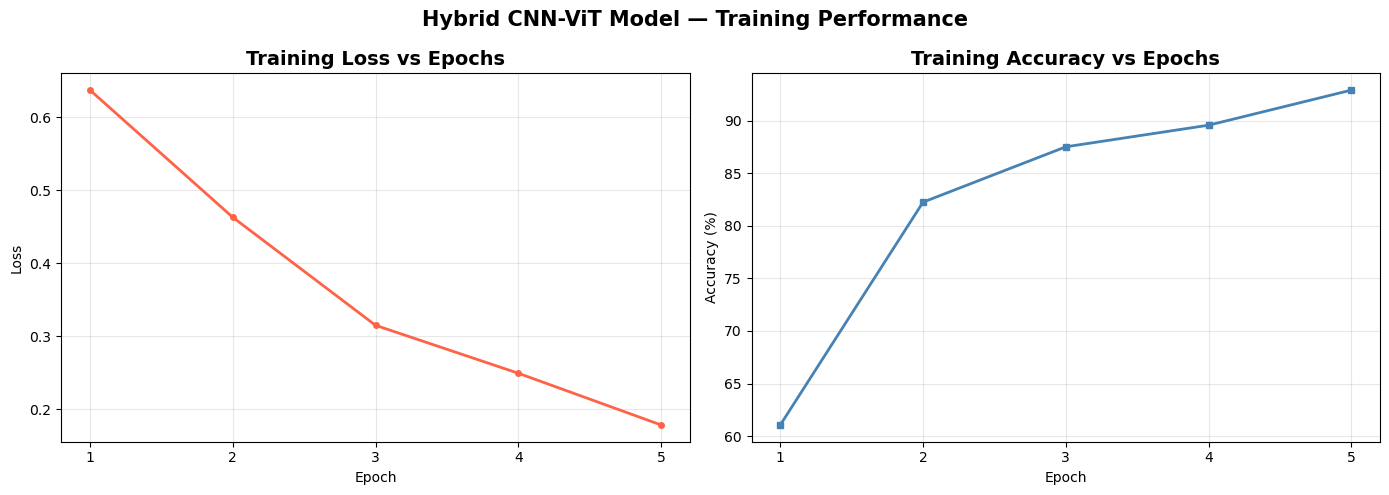

Graph saved as training_graphs.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epoch_range = range(1, EPOCHS + 1)

# ── Loss Graph ──
axes[0].plot(epoch_range, train_losses, color='tomato', linewidth=2, marker='o', markersize=4)
axes[0].set_title('Training Loss vs Epochs', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(epoch_range)

# ── Accuracy Graph ──
axes[1].plot(epoch_range, [a * 100 for a in train_accuracies],
             color='steelblue', linewidth=2, marker='s', markersize=4)
axes[1].set_title('Training Accuracy vs Epochs', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(epoch_range)

plt.suptitle('Hybrid CNN-ViT Model — Training Performance', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('training_graphs.png', dpi=150, bbox_inches='tight')
plt.show()
print("Graph saved as training_graphs.png")

## 🧪 Section 11: Model Evaluation on Test Set

In [12]:
model.eval()

all_preds  = []
all_labels = []
all_probs  = []

with torch.no_grad():
    for images, lbls in test_loader:
        images = images.to(device)
        lbls   = lbls.to(device)

        outputs = model(images).squeeze()
        preds   = (outputs > 0.5).int()

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(lbls.cpu().numpy())
        all_probs.extend(outputs.cpu().numpy())

# ── Accuracy ──
accuracy = accuracy_score(all_labels, all_preds)
print(f"\n{'='*40}")
print(f"  MODEL EFFICIENCY (Accuracy) : {accuracy * 100:.2f}%")
print(f"{'='*40}")


  MODEL EFFICIENCY (Accuracy) : 86.15%


## 📋 Section 12: Classification Report (Precision, Recall, F1)

In [13]:
print("\nDetailed Classification Report:")
print("-" * 50)
print(classification_report(
    all_labels,
    all_preds,
    target_names=["Real (0)", "AI-Generated (1)"]
))


Detailed Classification Report:
--------------------------------------------------
                  precision    recall  f1-score   support

        Real (0)       0.82      0.89      0.85        87
AI-Generated (1)       0.90      0.84      0.87       108

        accuracy                           0.86       195
       macro avg       0.86      0.86      0.86       195
    weighted avg       0.86      0.86      0.86       195



## 🎯 Section 13: Confusion Matrix

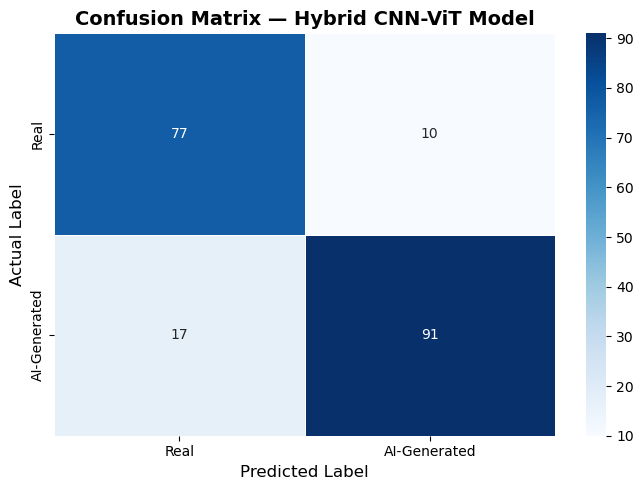


True  Negatives (Real correctly identified)     : 77
True  Positives (AI correctly identified)       : 91
False Positives (Real wrongly flagged as AI)    : 10
False Negatives (AI wrongly flagged as Real)    : 17


In [14]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Real', 'AI-Generated'],
    yticklabels=['Real', 'AI-Generated'],
    linewidths=0.5
)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('Actual Label',    fontsize=12)
plt.title('Confusion Matrix — Hybrid CNN-ViT Model', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Breakdown
tn, fp, fn, tp = cm.ravel()
print(f"\nTrue  Negatives (Real correctly identified)     : {tn}")
print(f"True  Positives (AI correctly identified)       : {tp}")
print(f"False Positives (Real wrongly flagged as AI)    : {fp}")
print(f"False Negatives (AI wrongly flagged as Real)    : {fn}")

## 💾 Section 14: Save the Model

In [15]:
torch.save(model.state_dict(), 'hybrid_model.pth')
print("Model saved as hybrid_model.pth ✅")

Model saved as hybrid_model.pth ✅


## 🔮 Section 15: Predict on a Single Image

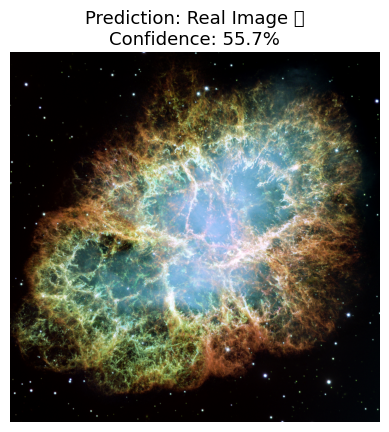

Raw probability : 0.4431
Prediction      : Real Image 📷
Confidence      : 55.69%


In [38]:
def predict_image(image_path):
    """
    Pass any image path → get Real or AI-Generated prediction
    """
    model.eval()

    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
    ])

    img = Image.open(image_path).convert("RGB")
    img_tensor = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        prob = model(img_tensor).item()

    label  = "AI-Generated 🤖" if prob > 0.5 else "Real Image 📷"
    confidence = prob * 100 if prob > 0.5 else (1 - prob) * 100

    # Show image
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Prediction: {label}\nConfidence: {confidence:.1f}%", fontsize=13)
    plt.show()

    print(f"Raw probability : {prob:.4f}")
    print(f"Prediction      : {label}")
    print(f"Confidence      : {confidence:.2f}%")


# ✅ TO USE: Replace path below with any image you want to test
#predict_image(r"C:\Users\visha\Desktop\dataset\real\2g24m0k80001000.png")
predict_image(r"C:\Users\visha\Desktop\New folder\1.png")
